Train shape: (736, 7)
Test shape:  (739, 7)

=== TRAINING START ===

Episode 0 | Reward: -19.74 | Epsilon: 0.995
Episode 10 | Reward: -76.23 | Epsilon: 0.946
Episode 20 | Reward: -39.74 | Epsilon: 0.900
Episode 30 | Reward: -5.22 | Epsilon: 0.856
Episode 40 | Reward: -72.17 | Epsilon: 0.814
Episode 50 | Reward: -10.29 | Epsilon: 0.774
Episode 60 | Reward: -2.81 | Epsilon: 0.737
Episode 70 | Reward: -7.03 | Epsilon: 0.701
Episode 80 | Reward: -4.33 | Epsilon: 0.666
Episode 90 | Reward: -1.76 | Epsilon: 0.634
Episode 100 | Reward: -1.14 | Epsilon: 0.603
Episode 110 | Reward: -0.88 | Epsilon: 0.573
Episode 120 | Reward: 1.54 | Epsilon: 0.545
Episode 130 | Reward: 1.01 | Epsilon: 0.519
Episode 140 | Reward: 0.10 | Epsilon: 0.493
Episode 150 | Reward: 1.43 | Epsilon: 0.469
Episode 160 | Reward: 1.77 | Epsilon: 0.446
Episode 170 | Reward: 2.60 | Epsilon: 0.424
Episode 180 | Reward: 1.01 | Epsilon: 0.404
Episode 190 | Reward: 2.06 | Epsilon: 0.384

=== TEST EVALUATION ===



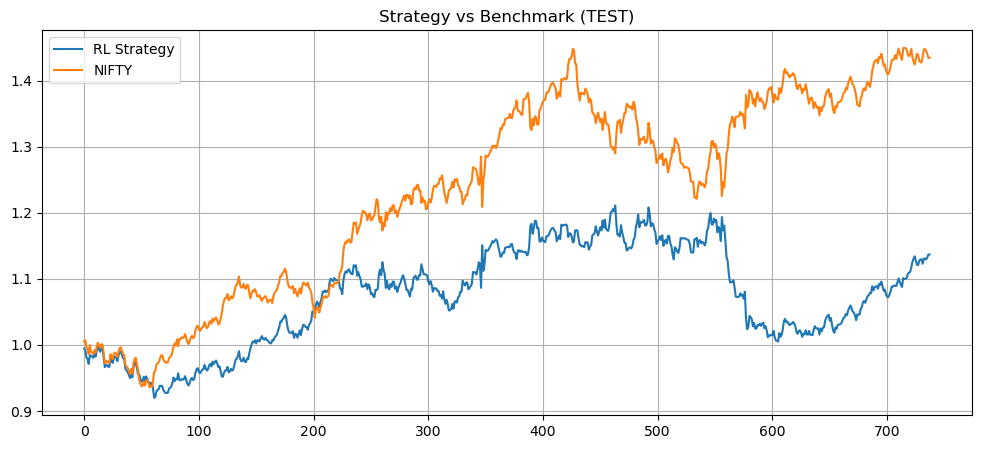

=== PERFORMANCE ===
CAGR: 4.48%
Volatility: 11.60%
Sharpe: -0.125
Max Drawdown: -17.00%


In [1]:
# =============================================
# DAY 35 — FINAL TRAINING + TEST EVALUATION
# =============================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. LOAD DATA
# =============================================
state_data = pd.read_csv("../data/state_dataset.csv", index_col=0)
market_data = pd.read_csv("../data/market_master.csv", index_col=0)

state_data.index = pd.to_datetime(state_data.index)
market_data.index = pd.to_datetime(market_data.index)

data = state_data.join(market_data[["nifty_ret"]], how="inner")

# Train/Test Split
train_data = data.loc["2019":"2022"]
test_data  = data.loc["2023":"2025"]

print(f"Train shape: {train_data.shape}")
print(f"Test shape:  {test_data.shape}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 2. ENVIRONMENT (FIXED VERSION)
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.n_features = data.shape[1] - 1
        self.max_steps = len(data) - 1
        
        self.reset()
    
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        self.peak = 1.0
        
        return self._get_observation()
    
    def _get_observation(self):
        obs = self.data.iloc[self.current_step].values[:-1]
        return np.append(obs, self.position)
    
    def step(self, action):
        
        prev_position = self.position
        
        # Actions: 0 = short, 1 = flat, 2 = long
        self.position = action - 1
        
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        
        # Transaction cost
        cost = abs(self.position - prev_position) * 0.0005
        
        net_ret = self.position * ret - cost
        
        # Update balance
        self.balance *= (1 + net_ret)
        self.peak = max(self.peak, self.balance)
        
        drawdown = (self.balance - self.peak) / self.peak
        
        # Reward (learning signal)
        reward = net_ret - 0.08*(net_ret**2)
        if drawdown < -0.05:
            reward -= 0.25 * abs(drawdown)
        
        self.current_step += 1
        done = self.current_step >= self.max_steps
        
        return self._get_observation(), reward, done, {"net_ret": net_ret}

# =============================================
# 3. DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, action_size)
        )
    
    def forward(self, x):
        return self.net(x)

# =============================================
# 4. REPLAY BUFFER
# =============================================
class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, *args):
        self.buffer.append(args)
    
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        
        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).to(device),
            torch.FloatTensor(rewards).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).to(device)
        )
    
    def __len__(self):
        return len(self.buffer)

# =============================================
# 5. INITIALIZE
# =============================================
train_env = QuantumAlphaEnv(train_data)
test_env  = QuantumAlphaEnv(test_data)

state_size = train_env.n_features + 1
action_size = 3

policy_net = DQN(state_size, action_size).to(device)
target_net = DQN(state_size, action_size).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
criterion = nn.SmoothL1Loss()

memory = ReplayBuffer()

# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995
batch_size = 128
target_update = 500
warmup = 500

# =============================================
# 6. TRAINING LOOP
# =============================================
num_episodes = 200
global_step = 0
best_reward = -np.inf

print("\n=== TRAINING START ===\n")

for ep in range(num_episodes):
    
    state = train_env.reset()
    total_reward = 0
    
    while True:
        
        # Action selection
        if random.random() < epsilon:
            action = random.randint(0, 2)
        else:
            with torch.no_grad():
                s = torch.FloatTensor(state).unsqueeze(0).to(device)
                action = policy_net(s).argmax().item()
        
        next_state, reward, done, _ = train_env.step(action)
        
        memory.push(state, action, reward, next_state, done)
        state = next_state
        
        total_reward += reward
        global_step += 1
        
        # Train
        if len(memory) > warmup:
            states, actions, rewards, next_states, dones = memory.sample(batch_size)
            
            current_q = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze()
            
            with torch.no_grad():
                next_q = target_net(next_states).max(1)[0]
                target_q = rewards + gamma * next_q * (1 - dones)
            
            loss = criterion(current_q, target_q)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 1.0)
            optimizer.step()
        
        # Target update
        if global_step % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())
        
        if done:
            break
    
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    
    if total_reward > best_reward:
        best_reward = total_reward
        torch.save(policy_net.state_dict(), "../models/dqn_best.pth")
    
    if ep % 10 == 0:
        print(f"Episode {ep} | Reward: {total_reward:.2f} | Epsilon: {epsilon:.3f}")

# =============================================
# 7. EVALUATION FUNCTION
# =============================================
def evaluate_agent(env, model):
    
    state = env.reset()
    done = False
    
    equity = 1.0
    equity_curve = []
    returns = []
    
    while not done:
        
        with torch.no_grad():
            s = torch.FloatTensor(state).unsqueeze(0).to(device)
            action = model(s).argmax().item()
        
        next_state, reward, done, info = env.step(action)
        
        net_ret = info["net_ret"]
        
        equity *= (1 + net_ret)
        
        equity_curve.append(equity)
        returns.append(net_ret)
        
        state = next_state
    
    return equity_curve, returns

# =============================================
# 8. TEST EVALUATION
# =============================================
print("\n=== TEST EVALUATION ===\n")

test_curve, test_returns = evaluate_agent(test_env, policy_net)

# Benchmark
benchmark = (1 + test_data["nifty_ret"]).cumprod()

# Plot
plt.figure(figsize=(12,5))
plt.plot(test_curve, label="RL Strategy")
plt.plot(benchmark.values[:len(test_curve)], label="NIFTY")
plt.legend()
plt.title("Strategy vs Benchmark (TEST)")
plt.grid(True)
plt.show()

# =============================================
# 9. METRICS
# =============================================
test_returns = np.array(test_returns)

days = len(test_returns)

cagr = (test_curve[-1]) ** (252 / days) - 1
vol = np.std(test_returns) * np.sqrt(252)
rf = 0.065 / 252
sharpe = (np.mean(test_returns) - rf) / (np.std(test_returns) + 1e-8) * np.sqrt(252)

equity_arr = np.array(test_curve)
rolling_max = np.maximum.accumulate(equity_arr)
drawdown = (equity_arr - rolling_max) / rolling_max
max_dd = drawdown.min()

print("=== PERFORMANCE ===")
print(f"CAGR: {cagr:.2%}")
print(f"Volatility: {vol:.2%}")
print(f"Sharpe: {sharpe:.3f}")
print(f"Max Drawdown: {max_dd:.2%}")

# =============================================
# 10. SAVE
# =============================================
results = pd.DataFrame({
    "equity": test_curve,
    "returns": test_returns
})

results.to_csv("../backtesting/rl_test_results.csv")